# Jupyter Notebook Explanation

## Overview
This notebook analyzes and visualizes the activation of pure purple filters in given data by performing the following tasks:

1. **Plotting Histograms of Pure Purple Filters**
   - The notebook generates histograms of filter activations for values in the range (1.0 - 1.1).

2. **Determining Activation Threshold Exceedance**
   - It computes the number of filters that activate pure-purple for all (beyond  a specified threshold) images



In [1]:
%matplotlib inline
import os
import numpy as np
from tensorflow.keras.models import Model, load_model

2025-01-31 08:52:31.686018: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1738313551.700433    6970 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1738313551.704788    6970 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-01-31 08:52:31.719709: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
os.chdir('For Victor/amfinder-release-v2.1.2/amfinder/amf')
print(os.getcwd())
print(os.listdir())

/home/victor/Saliency Maps/For Victor/amfinder-release-v2.1.2/amfinder/amf
['colonized_activations.npy', 'all_activations.npy', 'amf', 'amfinder_predict.py', 'spatial_colonized_activations.npy', 'requirements_dev.txt', 'amfinder_config.py', 'requirements.txt', 'filter_visualization.py', 'embeddings_full_mis.npy', 'no_root_activations.npy', 'uncolonized_activations.npy', 'Correctly classified vs Misclassified data histogram plot.png', 'pure_purple_analysis.py', 'amfinder_model.py', 'amfinder_diagnose.py', 'Correct Data vs Misclassified Data for non-colonized roots.png', 'test_metrics.py', 'visualize_UMAP.py', 'trained_networks', 'amfinder_load.py', 'amfinder_tile_convert.py', '__pycache__', 'amfinder_test.py', 'amfinder_segmentation.py', 'install.sh', 'amfinder_image.py', 'metrics_collector.py', 'amfinder_altmodel.py', 'amfinder_calc.py', 'preprocessing.py', 'build', 'amfinder_plot.py', 'amfinder_train.py', 'split_data.py', 'amfinder_save.py', 'amfinder_superresolution.py', 'spatial_unc

In [3]:
from pure_purple_analysis import split_data_by_classification, analyze_no_root_filter_statistics, find_pure_purple_filters

In [ ]:
model = load_model('../legacy_trained_networks/252_tile.h5')
layer_model = Model(inputs=model.input,
                    outputs=model.get_layer('C4').output)


I0000 00:00:1738311382.840662   45593 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5710 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2080 SUPER, pci bus id: 0000:2d:00.0, compute capability: 7.5
/home/victor/Saliency Maps/.venv/lib/python3.10/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


# Load Data

In [6]:
#seperate mis and correctly classified within test 

#load data
x_spring_0 = np.load('Preprocessed_data/Data/Test/x_test_spring_0.npy')
x_spring_1 = np.load('Preprocessed_data/Data/Test/x_test_spring_1.npy')
x_summer_0 = np.load('Preprocessed_data/Data/Test/x_test_summer_0.npy')

#load true labels
x_spring_0_true = np.load('Preprocessed_data/Labels/True/y_test_spring_0.npy')
x_spring_0_true = np.argmax(x_spring_0_true, axis = 1)

x_spring_1_true =np.load('Preprocessed_data/Labels/True/y_test_spring_1.npy')
x_spring_1_true = np.argmax(x_spring_1_true, axis = 1)

x_summer_0_true = np.load('Preprocessed_data/Labels/True/y_test_summer_0.npy')
x_summer_0_true = np.argmax(x_summer_0_true, axis = 1)

#load predicted labels
x_spring_0_predicted = np.load('Preprocessed_data/Labels/Predicted/y_test_spring_0_predicted.npy')
x_spring_0_predicted = np.argmax(x_spring_0_predicted, axis = 1)

x_spring_1_predicted =np.load('Preprocessed_data/Labels/Predicted/y_test_spring_1_predicted.npy')
x_spring_1_predicted = np.argmax(x_spring_1_predicted, axis = 1)

x_summer_0_predicted = np.load('Preprocessed_data/Labels/Predicted/y_test_summer_0_predicted.npy')
x_summer_0_predicted = np.argmax(x_summer_0_predicted, axis = 1)

In [7]:
cor_x_1, mis_x_1, cor_labels_1, mis_tlabel_1, mis_plabel_1 = split_data_by_classification(x_spring_0_true, x_spring_0_predicted, x_spring_0)
cor_x_2, mis_x_2, cor_labels_2, mis_tlabel_2, mis_plabel_2  = split_data_by_classification(x_spring_1_true, x_spring_1_predicted, x_spring_1)
cor_x_3, mis_x_3, cor_labels_3, mis_tlabel_3, mis_plabel_3  = split_data_by_classification(x_summer_0_true, x_summer_0_predicted, x_summer_0)

In [8]:
#free memory 
del x_spring_0, x_spring_1, x_summer_0, x_spring_0_true, x_spring_1_true, x_summer_0_true, x_spring_0_predicted, x_spring_1_predicted, x_summer_0_predicted

In [9]:
#structure data
correct_data = np.concatenate((cor_x_1, cor_x_2, cor_x_3), axis=0)
cor_labels = np.concatenate((cor_labels_1, cor_labels_2, cor_labels_3), axis=0)

misclassified_data= np.concatenate((mis_x_1, mis_x_2, mis_x_3), axis=0)
mis_labels = np.concatenate((mis_tlabel_1, mis_tlabel_2, mis_tlabel_3), axis=0)

cor_root_indices = np.where(cor_labels != 2)[0]
mis_root_indices = np.where(mis_labels != 2)[0]

correct_data = correct_data[cor_root_indices]
misclassified_data = misclassified_data[mis_root_indices]

print(correct_data.shape)
print(misclassified_data.shape)

(2156, 252, 252, 3)
(1526, 252, 252, 3)


In [10]:
#free memory
del cor_x_1, cor_x_2, cor_x_3, cor_labels_1, cor_labels_2, cor_labels_3, mis_x_1, mis_x_2, mis_x_3, mis_tlabel_1, mis_tlabel_2, mis_tlabel_3

# 1.0 Average % of no-root activations of root samples

I0000 00:00:1738308380.058088   22209 service.cc:148] XLA service 0x7f06e4104d80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1738308380.058829   22209 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 2080 SUPER, Compute Capability 7.5
2025-01-31 07:26:20.079200: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1738308380.126914   22209 cuda_dnn.cc:529] Loaded cuDNN version 90600
2025-01-31 07:26:20.474470: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[32,32,250,250]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,3,252,252]{3,2,1,0}, f32[32,3,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config"

 5/68 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step

I0000 00:00:1738308382.979840   22209 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


67/68 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step

2025-01-31 07:26:25.507241: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[12,32,250,250]{3,2,1,0}, u8[0]{0}) custom-call(f32[12,3,252,252]{3,2,1,0}, f32[32,3,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]}
2025-01-31 07:26:25.571506: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[12,32,248,248]{3,2,1,0}, u8[0]{0}) custom-call(f32[12,32,250,250]{3,2,1,0}, f32[32,32,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend

68/68 ━━━━━━━━━━━━━━━━━━━━ 7s 56ms/step
47/48 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step

2025-01-31 07:26:30.939764: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[22,32,250,250]{3,2,1,0}, u8[0]{0}) custom-call(f32[22,3,252,252]{3,2,1,0}, f32[32,3,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]}
2025-01-31 07:26:31.018501: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[22,32,248,248]{3,2,1,0}, u8[0]{0}) custom-call(f32[22,32,250,250]{3,2,1,0}, f32[32,32,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend

48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step

Statistical Analysis of No-Root Filters:
Correctly Classified - Mean: 179.44, Std: 53.77
Misclassified       - Mean: 164.36, Std: 56.53
T-test - t-statistic: 8.21, p-value: 0.0000
The difference is statistically significant (p < 0.05).


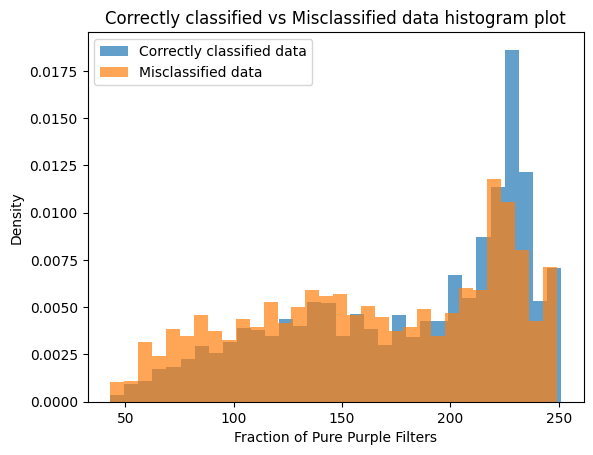

In [19]:
stats_c4_full = analyze_no_root_filter_statistics(model = model, layer_name = 'C4', 
                                                  data_1 = correct_data, 
                                                  data_2 = misclassified_data,
                                                  data_1_title = 'Correctly classified data',
                                                  data_2_title = 'Misclassified data',
                                                  bins = 32,
                                                  title = 'Correctly classified vs Misclassified data histogram plot')



In [ ]:
plt.savefig('../../../../Figures/Filter_analysis/Correct_mis_his_plot', dpi=300, bbox_inches='tight')


# 1.1 Non-colonized and Colonized analysis

In [8]:
#structure data
correct_data = np.concatenate((cor_x_1, cor_x_2, cor_x_3), axis=0)
cor_labels = np.concatenate((cor_labels_1, cor_labels_2, cor_labels_3), axis=0)

misclassified_data= np.concatenate((mis_x_1, mis_x_2, mis_x_3), axis=0)
mis_labels = np.concatenate((mis_tlabel_1, mis_tlabel_2, mis_tlabel_3), axis=0)

#non_colonized
cor_non_colonized_indices = np.where(cor_labels == 1)[0]
mis_non_colonized_indices = np.where(mis_labels == 1)[0]

#colonized
cor_colonized_indices = np.where(cor_labels == 0)[0]
mis_colonized_indices = np.where(mis_labels == 0)[0]

#data
#non-colonized
correct_data_non_colonized = correct_data[cor_non_colonized_indices]
misclassified_data_non_colonized = misclassified_data[mis_non_colonized_indices]

#colonized
correct_data_colonized = correct_data[cor_colonized_indices]
misclassified_data_colonized = misclassified_data[mis_colonized_indices]

#for comparing non-colonized and colonized (was not shown in report)
all_non_colonized = np.concatenate((correct_data_non_colonized, misclassified_data_non_colonized), axis = 0)
all_colonized = np.concatenate((correct_data_colonized, misclassified_data_colonized), axis = 0)



In [9]:
del correct_data_colonized, misclassified_data_colonized, correct_data_non_colonized, misclassified_data_non_colonized

I0000 00:00:1738308492.628236   23302 service.cc:148] XLA service 0x7f38b4105100 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1738308492.628282   23302 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 2080 SUPER, Compute Capability 7.5
2025-01-31 07:28:12.635769: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1738308492.663064   23302 cuda_dnn.cc:529] Loaded cuDNN version 90600
2025-01-31 07:28:12.867544: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[32,32,250,250]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,3,252,252]{3,2,1,0}, f32[32,3,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config"

 5/62 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step

I0000 00:00:1738308495.196313   23302 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


62/62 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step
46/47 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

2025-01-31 07:28:22.263967: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[15,32,250,250]{3,2,1,0}, u8[0]{0}) custom-call(f32[15,3,252,252]{3,2,1,0}, f32[32,3,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]}
2025-01-31 07:28:22.320298: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[15,32,248,248]{3,2,1,0}, u8[0]{0}) custom-call(f32[15,32,250,250]{3,2,1,0}, f32[32,32,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend

47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step

Statistical Analysis of No-Root Filters:
Correctly Classified - Mean: 178.22, Std: 54.25
Misclassified       - Mean: 163.38, Std: 56.69
T-test - t-statistic: 7.82, p-value: 0.0000
The difference is statistically significant (p < 0.05).


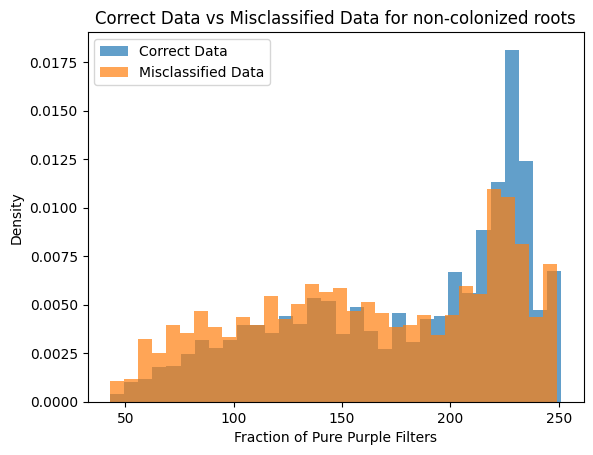

In [10]:
stats_c4_non_colonized =analyze_no_root_filter_statistics(model = model, layer_name = 'C4', 
                                                          data_1 = correct_data_non_colonized, 
                                                          data_2 = misclassified_data_non_colonized,
                                                          data_1_title = 'Correct Data',
                                                          data_2_title = 'Misclassified Data',
                                                          bins = 32,
                                                          title = 'Correct Data vs Misclassified Data for non-colonized roots' )


5/6 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

2025-01-31 07:28:32.987868: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[12,32,250,250]{3,2,1,0}, u8[0]{0}) custom-call(f32[12,3,252,252]{3,2,1,0}, f32[32,3,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]}
2025-01-31 07:28:33.041026: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[12,32,248,248]{3,2,1,0}, u8[0]{0}) custom-call(f32[12,32,250,250]{3,2,1,0}, f32[32,32,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 291ms/step


1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step

2025-01-31 07:28:34.627693: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[7,32,250,250]{3,2,1,0}, u8[0]{0}) custom-call(f32[7,3,252,252]{3,2,1,0}, f32[32,3,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]}
2025-01-31 07:28:34.666814: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[7,32,248,248]{3,2,1,0}, u8[0]{0}) custom-call(f32[7,32,250,250]{3,2,1,0}, f32[32,32,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_con

2025-01-31 07:28:35.300950: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[7,256,25,25]{3,2,1,0}, u8[0]{0}) custom-call(f32[7,128,27,27]{3,2,1,0}, f32[256,128,3,3]{3,2,1,0}, f32[256]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]}


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 996ms/step

Statistical Analysis of No-Root Filters:
Correctly Classified - Mean: 193.53, Std: 45.57
Misclassified       - Mean: 201.46, Std: 32.77
T-test - t-statistic: -1.02, p-value: 0.3072
The difference is not statistically significant (p >= 0.05).


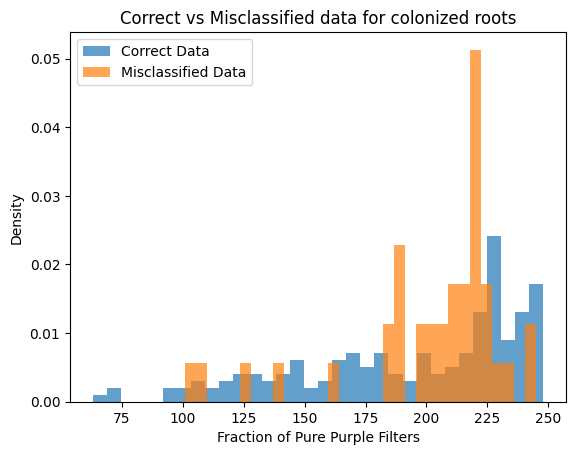

In [11]:
stats_c4_colonized = analyze_no_root_filter_statistics(model = model, layer_name = 'C4', 
                                                       data_1 = correct_data_colonized, 
                                                       data_2 = misclassified_data_colonized,
                                                       data_1_title = 'Correct Data',
                                                       data_2_title = 'Misclassified Data',
                                                       bins = 32,
                                                       title = 'Correct vs Misclassified data for colonized roots')

# 2.0 Filters that Always Activate no-root

In [10]:
cor_pure_purple = find_pure_purple_filters(data = correct_data ,
                                           model = model ,
                                           layer_name = 'C4',
                                            threshold = 0.95
)

2025-01-31 08:17:50.289071: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 1642975488 exceeds 10% of free system memory.
2025-01-31 08:17:51.272836: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 1642975488 exceeds 10% of free system memory.
I0000 00:00:1738311471.934946   45743 service.cc:148] XLA service 0x7fc9941053d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1738311471.934995   45743 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 2080 SUPER, Compute Capability 7.5
2025-01-31 08:17:51.942032: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1738311471.974005   45743 cuda_dnn.cc:529] Loaded cuDNN version 90600
2025-01-31 08:17:52.191931: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potenti

 5/68 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step

I0000 00:00:1738311474.749132   45743 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


67/68 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step

2025-01-31 08:17:57.408823: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[12,32,250,250]{3,2,1,0}, u8[0]{0}) custom-call(f32[12,3,252,252]{3,2,1,0}, f32[32,3,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]}
2025-01-31 08:17:57.461516: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[12,32,248,248]{3,2,1,0}, u8[0]{0}) custom-call(f32[12,32,250,250]{3,2,1,0}, f32[32,32,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend

68/68 ━━━━━━━━━━━━━━━━━━━━ 7s 59ms/step


2025-01-31 08:17:58.798782: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 1379840000 exceeds 10% of free system memory.


In [11]:
mis_pure_purple = find_pure_purple_filters(data = misclassified_data ,
                                           model = model ,
                                           layer_name = 'C4',
                                            threshold = 0.95
)

2025-01-31 08:18:26.432120: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 1162885248 exceeds 10% of free system memory.
2025-01-31 08:18:27.043599: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 1162885248 exceeds 10% of free system memory.


47/48 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step

2025-01-31 08:18:29.571172: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[22,32,250,250]{3,2,1,0}, u8[0]{0}) custom-call(f32[22,3,252,252]{3,2,1,0}, f32[32,3,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]}
2025-01-31 08:18:29.650387: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[22,32,248,248]{3,2,1,0}, u8[0]{0}) custom-call(f32[22,32,250,250]{3,2,1,0}, f32[32,32,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend

48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step


In [12]:
print(len(cor_pure_purple), len(mis_pure_purple))

48 40


In [3]:
repeated_filters_dict = {
    key: (mis_pure_purple[key], cor_pure_purple[key]) 
    for key in mis_pure_purple if key in cor_pure_purple
}

NameError: name 'mis_pure_purple' is not defined

In [4]:
len(repeated_filters_dict)

NameError: name 'repeated_filters_dict' is not defined